# Comparaison des modèles (Students Social Media Addiction)

**Dataset :** Students Social Media Addiction  
**Variable cible :** `Addicted_Score` score d'addiction de 2 à 9  

Ce notebook charge les données, fait le preprocessing, puis appelle chaque modèle depuis le dossier `models/`.  
Il compare ensuite les résultats et propose un exemple d'application concret.

## 1 - Importation des bibliothèques

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('..')

from sklearn.model_selection import train_test_split
from models.encoder import labelEncoder, oneHotEncoder


## 2 - Chargement et preprocessing

On charge le dataset, on supprime la colonne `Student_ID` (identifiant sans valeur prédictive),  
et on convertit les variables textuelles en nombres avec `LabelEncoder`.  
Ensuite on sépare les données en 80% entraînement / 20% test.

In [5]:
from models.ACP import ACP


df = pd.read_csv('BDD_initial/Students Social Media Addiction.csv')
df = df.drop(columns=['Student_ID'])

X_raw = df.drop(columns=['Addicted_Score'])
y     = df['Addicted_Score']

# LabelEncoder
X_le  = labelEncoder(X_raw.copy())

# OneHotEncoder
X_ohe = oneHotEncoder(X_raw.copy())

# ACP
x_acp = ACP(X_ohe, n_components=50)

# Split — même random_state pour comparer sur les mêmes données
X_train_le,  X_test_le,  y_train_le, y_test_le = train_test_split(X_le,  y, test_size=0.2, random_state=42)
X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe= train_test_split(X_ohe, y, test_size=0.2, random_state=42)

X_train_acp, X_test_acp, y_train_acp, y_test_acp = train_test_split(x_acp, y, test_size=0.2, random_state=42)


# label_encoders conservé pour l'exemple étudiant (cell 16)
from sklearn.preprocessing import LabelEncoder
cat_cols = df.select_dtypes(include='object').columns.tolist()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(df[col])
    label_encoders[col] = le

print('X_le  shape:', X_le.shape)
print('X_ohe shape:', X_ohe.shape)
print('Train / Test:', X_train_le.shape[0], '/', X_test_le.shape[0])


X_le  shape: (705, 11)
X_ohe shape: (705, 137)
Train / Test: 564 / 141


C:\Users\sidsm\AppData\Local\Temp\ipykernel_17704\295372075.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


## 3. Entraînement des modèles

Chaque modèle est dans un fichier séparé dans `models/`.  
La fonction `run(X_train, X_test, y_train, y_test)` retourne un dictionnaire avec les métriques.

Tous les modèles sont présents en 2 versions : 
la version initial avec GridSearchCV est la meilleur mais peut prendre plusieurs minutes, la version 2 avec RandomizedSearchCV est plus courte mais moins précise. 

> **Pour ajouter un modèle** : importer sa fonction `run` et l'ajouter au dictionnaire `modeles`.

In [6]:

from models.random_forest_rgs_v2 import run as run_rf
from models.xgboost import run as run_xgb
from models.knn_rgs import run as run_knn
from models.naive_bayes_rgs_v2 import run as run_nb_rgs

modeles = {
    'KNN'          : run_knn,
    'Naive Bayes rgs'  : run_nb_rgs,
    'XGBoost'      : run_xgb,
    'Random Forest': run_rf,
}

resultats = {}
for nom, run_fn in modeles.items():
    print(f'Entraînement : {nom}...')
    resultats[f'{nom} (LE)']  = run_fn(X_train_le,  X_test_le,  y_train_le, y_test_le)
    resultats[f'{nom} (OHE)'] = run_fn(X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe)
    resultats[f'{nom} (ACP)'] = run_fn(X_train_acp, X_test_acp, y_train_acp, y_test_acp)

    print(f"  LE  R²: {resultats[f'{nom} (LE)']['optimized']['r2']:.4f}")
    print(f"  OHE R²: {resultats[f'{nom} (OHE)']['optimized']['r2']:.4f}")
    print(f"  ACP R²: {resultats[f'{nom} (ACP)']['optimized']['r2']:.4f}")

print('\nTerminé.')


Entraînement : KNN...
  LE  R²: 0.9883
  OHE R²: 0.9559
  ACP R²: 0.7621
Entraînement : Naive Bayes rgs...
  LE  R²: 0.9576
  OHE R²: 0.7866
  ACP R²: 0.7873
Entraînement : XGBoost...
  LE  R²: 0.9784
  OHE R²: 0.9862
  ACP R²: 0.9661
Entraînement : Random Forest...
  LE  R²: 0.9823
  OHE R²: 0.9903
  ACP R²: 0.9654

Terminé.


In [7]:
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression

# 1. Extraction des vrais modèles (estimateurs Scikit-Learn) 
estimators_acp = [
    ('KNN', resultats['KNN (ACP)']['model']),
    ('xgb', resultats['XGBoost (ACP)']['model']),
    ('rf', resultats['Random Forest (ACP)']['model'])
]

print('\nEntraînement des modèles d\'Ensemble...')

# 2. Voting Regressor (Fait la moyenne des prédictions)
model_voting = VotingRegressor(estimators=estimators_acp)

model_voting.fit(X_train_acp, y_train_acp) 
score_voting_acp = model_voting.score(X_test_acp, y_test_acp)

model_voting.fit(X_train_ohe, y_train_ohe) 
score_voting_ohe = model_voting.score(X_test_ohe, y_test_ohe)

model_voting.fit(X_train_le, y_train_le) 
score_voting_le = model_voting.score(X_test_le, y_test_le)

print(f"  Voting Regressor (ACP) R²: {score_voting_acp:.4f}")
print(f"  Voting Regressor (OHE) R²: {score_voting_ohe:.4f}")
print(f"  Voting Regressor (LE) R²: {score_voting_le:.4f}")

# 3. Stacking Regressor (Utilise un modèle final pour trancher)
model_stack = StackingRegressor(
    estimators=estimators_acp,
    final_estimator=LinearRegression(),
    cv=3 # Ajout de cv=3 pour accélérer l'entraînement interne
)
model_stack.fit(X_train_acp, y_train_acp)
score_stacking_acp = model_stack.score(X_test_acp, y_test_acp)

model_stack.fit(X_train_ohe, y_train_ohe) 
score_stacking_ohe = model_stack.score(X_test_ohe, y_test_ohe)

model_stack.fit(X_train_le, y_train_le) 
score_stacking_le = model_stack.score(X_test_le, y_test_le)

print(f"  Stacking Regressor (ACP) R²: {score_stacking_acp:.4f}")
print(f"  Stacking Regressor (OHE) R²: {score_stacking_ohe:.4f}")
print(f"  Stacking Regressor (LE) R²: {score_stacking_le:.4f}")


print('\nTerminé.')


Entraînement des modèles d'Ensemble...
  Voting Regressor (ACP) R²: 0.9582
  Voting Regressor (OHE) R²: 0.9862
  Voting Regressor (LE) R²: 0.9869
  Stacking Regressor (ACP) R²: 0.9665
  Stacking Regressor (OHE) R²: 0.9893
  Stacking Regressor (LE) R²: 0.9875

Terminé.


## 4. Tableau comparatif

On compare les modèles sur trois métriques :
- **R²** : proportion de variance expliquée (plus c'est proche de 1, mieux c'est)
- **MAE** : erreur moyenne en points de score
- **RMSE** : similaire au MAE, mais pénalise plus les grandes erreurs

In [8]:
rows = []
for nom, res in resultats.items():
    opt = res['optimized']
    rows.append({
        'Modèle': nom,
        'R²'    : round(opt['r2'],   4),
        'MAE'   : round(opt['mae'],  4),
        'RMSE'  : round(opt['rmse'], 4),
    })

df_comparaison = pd.DataFrame(rows).sort_values('R²', ascending=False).set_index('Modèle')
df_comparaison

,R²,MAE,RMSE
Modèle,,,
Random Forest (OHE),0.9903,0.0374,0.1555
KNN (LE),0.9883,0.0565,0.1710
XGBoost (OHE),0.9862,0.0602,0.1857
Random Forest (LE),0.9823,0.0781,0.2105
XGBoost (LE),0.9784,0.0908,0.2325
XGBoost (ACP),0.9661,0.1671,0.2914
Random Forest (ACP),0.9654,0.1547,0.2944
Naive Bayes rgs (LE),0.9576,0.1229,0.3257
KNN (OHE),0.9559,0.1617,0.3322


## 5. Visualisation des métriques

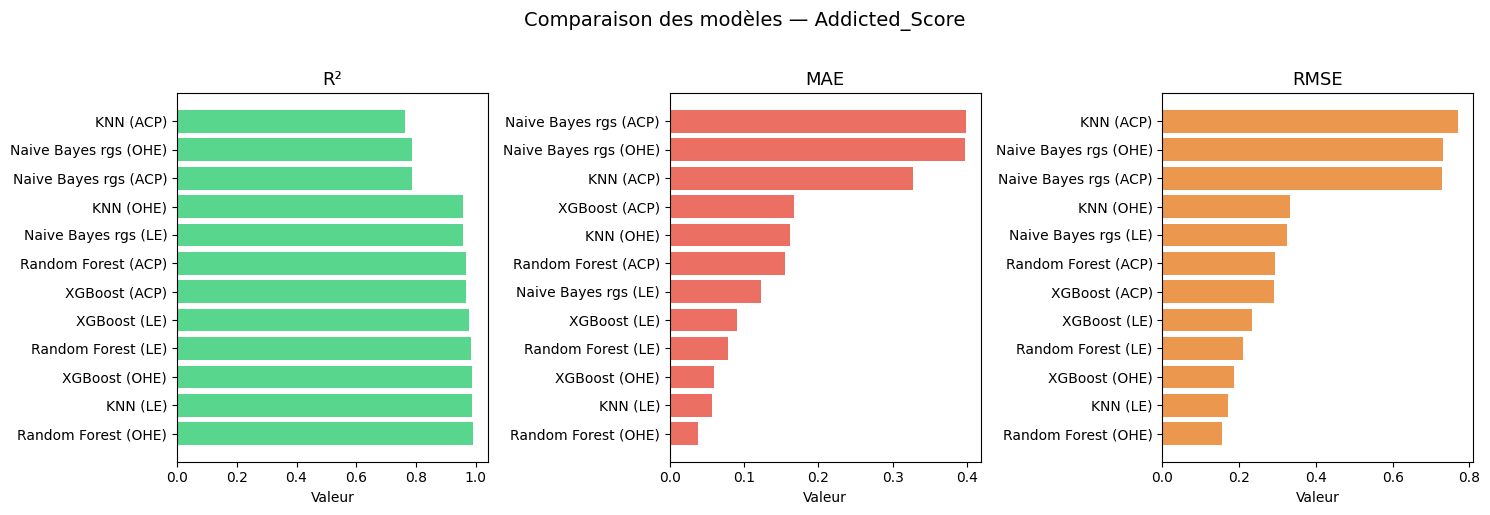

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [('R²', '#2ecc71', False), ('MAE', '#e74c3c', True), ('RMSE', '#e67e22', True)]

for ax, (metric, color, ascending) in zip(axes, metrics):
    vals = df_comparaison[metric].sort_values(ascending=ascending)
    ax.barh(vals.index, vals.values, color=color, alpha=0.8)
    ax.set_title(metric, fontsize=13)
    ax.set_xlabel('Valeur')

plt.suptitle('Comparaison des modèles — Addicted_Score', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Exemple d'application

On crée un profil d'étudiant fictif et on demande au modèle de prédire son score d'addiction.  
Les variables catégorielles sont encodées avec les mêmes `LabelEncoder` utilisés à l'étape 2.

In [8]:

# exemple d'un étudiant fictif
etudiant = {
    'Age'                          : 21,
    'Gender'                       : 'Female',
    'Academic_Level'               : 'Undergraduate',
    'Country'                      : 'France',
    'Avg_Daily_Usage_Hours'        : 0.0,
    'Most_Used_Platform'           : 'Instagram',
    'Affects_Academic_Performance' : 'Yes',
    'Sleep_Hours_Per_Night'        : 7.0,
    'Mental_Health_Score'          : 2,
    'Relationship_Status'          : 'Single',
    'Conflicts_Over_Social_Media'  : 0,
}

# trouve le meilleur modèle selon R²
meilleur_cle = max(resultats, key=lambda k: resultats[k]['optimized']['r2'])
meilleur_r2  = resultats[meilleur_cle]['optimized']['r2']

etudiant_df = pd.DataFrame([etudiant])

# encodage
etudiant_enc = {}
for col, val in etudiant.items():
    if col in label_encoders:
        etudiant_enc[col] = label_encoders[col].transform([val])[0]
    else:
        etudiant_enc[col] = val

if '(LE)' in meilleur_cle:
    X_etudiant = pd.DataFrame([etudiant_enc])[X_le.columns]
else:
    etudiant_ohe_raw = oneHotEncoder(etudiant_df.copy())
    X_etudiant       = etudiant_ohe_raw.reindex(columns=X_ohe.columns, fill_value=0)

score_predit = resultats[meilleur_cle]['model'].predict(X_etudiant)[0]

print("=== Profil de l'étudiant ===")
for k, v in etudiant.items():
    print(f"  {k:<35} : {v}")

print(f"\n Modèle utilisé : {meilleur_cle}  (R² = {meilleur_r2:.4f})")
print(f" Score prédit   : {score_predit:.2f} / 9")

if score_predit >= 7:
    print("    → Niveau élevé d'addiction")
elif score_predit >= 4:
    print("    → Niveau modéré d'addiction")
else:
    print("    → Niveau faible d'addiction")

=== Profil de l'étudiant ===
  Age                                 : 21
  Gender                              : Female
  Academic_Level                      : Undergraduate
  Country                             : France
  Avg_Daily_Usage_Hours               : 0.0
  Most_Used_Platform                  : Instagram
  Affects_Academic_Performance        : Yes
  Sleep_Hours_Per_Night               : 7.0
  Mental_Health_Score                 : 2
  Relationship_Status                 : Single
  Conflicts_Over_Social_Media         : 0

 Modèle utilisé : Random Forest (OHE)  (R² = 0.9903)
 Score prédit   : 7.59 / 9
    → Niveau élevé d'addiction


## 7. Conclusion

Ce notebook compare les modèles de régression entraînés sur le dataset `Students Social Media Addiction`.  
Le meilleur modèle est sélectionné selon le R² le plus élevé et le MAE/RMSE les plus faibles. Au vu des résultats observés dans les parties 4 et 5, le K-nearest neighboors s'impose comme le modèle le plus performant pour prédire les addictions aux réseaux sociaux, avec un R² de 0.9883 et les valeurs de MAE et RMSE les plus faibles parmi les modèles testés. 

**Pour intégrer un nouveau modèle :**
1. Créer `models/nom_du_modele.py` avec une fonction `run(X_train, X_test, y_train, y_test) -> dict`
2. La fonction doit retourner au minimum : `{'optimized': {'r2', 'mae', 'rmse'}, 'model': estimateur}`
3. Décommenter la ligne d'import correspondante dans la cellule 4

Le random forest et xgboost semblent être les modèles les plus performants sur ce dataset. Les modèles d'ensembles (voting, stacking) apportent une légère amélioration supplémentaire en combinant leurs prédictions.  